<a href="https://colab.research.google.com/github/naamasarshalom-art/segmentation_cellpose/blob/main/4_model1_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 1 — Quality Control Classifier (Classifiable vs Trash)

This notebook trains **Model 1**: a binary classifier that separates
classifiable nuclei (good + invaginated + unclassifiable) from trash/artifacts.

**Input:** RADIO embeddings computed in notebook `3_RADIO_embeddings.ipynb`

**Pipeline:**
1. Load embeddings and remap labels to binary (classifiable=0, trash=1)
2. Train / test split
3. Visualize embedding space (PCA 2D)
4. Scale data + PCA exploration (variance explained)
5. Grid search: SVM, LR, RF, LDA across hyperparameters and PCA configs
6. Train final model (best config selected automatically)
7. Evaluate on held-out test set
8. Error analysis by original nucleus class
9. Save model

**Output files:**
- `model1_scaler.pkl` — fitted StandardScaler
- `model1_svm.pkl` — trained classifier


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.pipeline import Pipeline

## 2. Configuration

In [3]:
# ── Input ──────────────────────────────────────────────────────────────────
EMBEDDINGS_PATH = "/content/drive/MyDrive/model_nuc/embeddings_radio.0.4.npz"

# ── Output ─────────────────────────────────────────────────────────────────
MODEL_DIR = "/content/drive/MyDrive/model_nuc"

# ── Label mapping — original 4 classes → binary ────────────────────────────
# 0=good, 1=invaginated, 2=Unclassifiable → classifiable (0)
# 3=trash                                 → trash (1)
LABEL_MAP = {0: 0, 1: 0, 2: 0, 3: 1}
CLASS_NAMES = {0: "classifiable", 1: "trash"}

# ── Reproducibility ────────────────────────────────────────────────────────
RANDOM_STATE = 42

## 3. Load Data & Prepare Binary Labels

In [4]:
data   = np.load(EMBEDDINGS_PATH, allow_pickle=True)
X_all  = data["X"]
labels = data["labels"]
paths  = data["paths"]

# Remap to binary labels
y = np.array([LABEL_MAP[l] for l in labels])

print(f"Embedding shape: {X_all.shape}")
print(f"\nClass distribution:")
for cls, name in CLASS_NAMES.items():
    n = (y == cls).sum()
    print(f"  {name:>15}: {n:>4} samples ({100*n/len(y):.1f}%)")
print(f"  {'Total':>15}: {len(y):>4}")

Embedding shape: (427, 2560)

Class distribution:
     classifiable:  245 samples (57.4%)
            trash:  182 samples (42.6%)
            Total:  427


## 4. Train / Test Split

20% held-out test set — not used until final evaluation.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples (held out)")

print("\nClass distribution:")
print(f"  {'Class':<20} {'Train':>8} {'Train%':>8} {'Test':>8} {'Test%':>8}")
print("  " + "-" * 52)
for cls, name in CLASS_NAMES.items():
    n_train = (y_train == cls).sum()
    n_test  = (y_test  == cls).sum()
    print(f"  {name:<20} {n_train:>8} {100*n_train/len(y_train):>7.1f}% {n_test:>8} {100*n_test/len(y_test):>7.1f}%")

Train: 341 samples
Test:  86 samples (held out)

Class distribution:
  Class                   Train   Train%     Test    Test%
  ----------------------------------------------------
  classifiable              196    57.5%       49    57.0%
  trash                     145    42.5%       37    43.0%


## 5. Embedding Space Visualization (PCA 2D)

Project the 2560-dim embeddings to 2D to check class separability
before training any classifier.

Explained variance: PC1=30.5%  PC2=10.0%


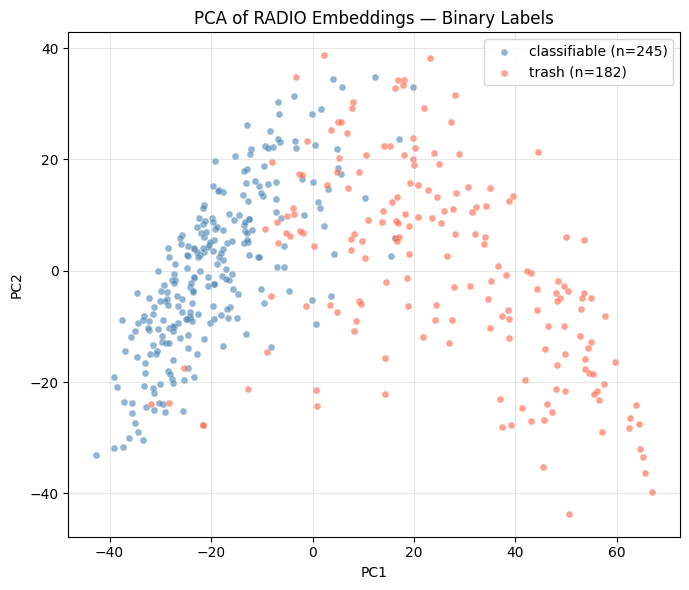

In [6]:
scaler_viz = StandardScaler()
X_scaled   = scaler_viz.fit_transform(X_all)

pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d    = pca_viz.fit_transform(X_scaled)

print(f"Explained variance: PC1={pca_viz.explained_variance_ratio_[0]:.1%}  "
      f"PC2={pca_viz.explained_variance_ratio_[1]:.1%}")

COLORS = {0: "steelblue", 1: "tomato"}

plt.figure(figsize=(7, 6))
for cls, name in CLASS_NAMES.items():
    mask = y == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=COLORS[cls], label=f"{name} (n={mask.sum()})",
                alpha=0.6, s=25, edgecolors="white", linewidth=0.3)

plt.title("PCA of RADIO Embeddings — Binary Labels")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Scale Data & PCA Exploration

Scale the training data with StandardScaler, then fit PCA to find
how many components are needed to explain 90%, 95%, and 99% of the variance.

  Components for 90% variance: 37
  Components for 95% variance: 68
  Components for 99% variance: 173


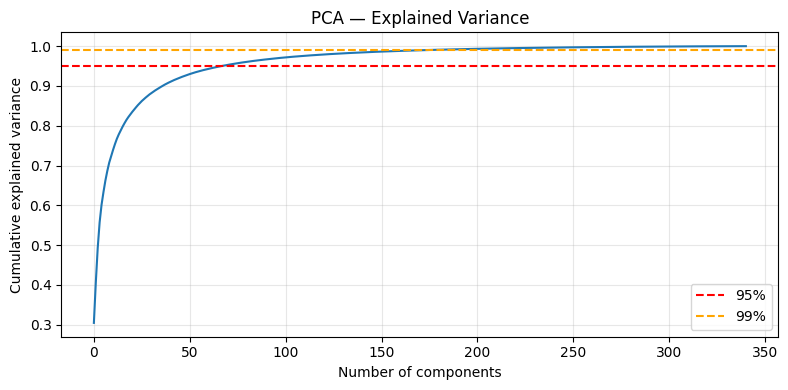

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ── Scale training data ────────────────────────────────────────────────────
# Must fit ONLY on train, then transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Fit PCA on all components ──────────────────────────────────────────────
pca_exp = PCA().fit(X_train_scaled)
cumvar  = np.cumsum(pca_exp.explained_variance_ratio_)

# Find how many components needed for 90%, 95%, 99% variance
for threshold in [0.90, 0.95, 0.99]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f"  Components for {threshold*100:.0f}% variance: {n}")

# ── Plot cumulative explained variance ─────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(cumvar)
plt.axhline(0.95, color='red',    linestyle='--', label='95%')
plt.axhline(0.99, color='orange', linestyle='--', label='99%')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Model Selection — Grid Search

Compare SVM, Logistic Regression, Random Forest, and LDA
across different hyperparameters and PCA configurations.
All evaluation is done with 5-fold cross-validation on the training set only.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score, accuracy_score
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy":               "accuracy",
    "f1_macro":               "f1_macro",
    "f1_classifiable":        make_scorer(f1_score,        average=None, labels=[0]),
    "f1_trash":               make_scorer(f1_score,        average=None, labels=[1]),
    "recall_classifiable":    make_scorer(recall_score,    average=None, labels=[0]),
    "recall_trash":           make_scorer(recall_score,    average=None, labels=[1]),
    "precision_classifiable": make_scorer(precision_score, average=None, labels=[0]),
    "precision_trash":        make_scorer(precision_score, average=None, labels=[1]),
}

PCA_OPTIONS = {
    "no_PCA": None,
    "PCA_90": 37,
    "PCA_95": 68,
    "PCA_99": 173,
}

MODELS = {
    "SVM_C0.1": SVC(kernel="rbf", C=0.1, class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    "SVM_C1":   SVC(kernel="rbf", C=1.0, class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    "SVM_C5":   SVC(kernel="rbf", C=5.0, class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    "LR_C0.1":  LogisticRegression(C=0.1, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    "LR_C1":    LogisticRegression(C=1.0, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    "LR_C10":   LogisticRegression(C=10,  class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    "RF_100":   RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE),
    "RF_300":   RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "LDA":      LinearDiscriminantAnalysis(),
}

# Build all pipelines
CONFIGS = {}
for model_name, model in MODELS.items():
    for pca_name, n_components in PCA_OPTIONS.items():
        config_name = f"{model_name}__{pca_name}"
        steps = [("scaler", StandardScaler())]
        if n_components is not None:
            steps.append(("pca", PCA(n_components=n_components, random_state=RANDOM_STATE)))
        steps.append(("clf", model))
        CONFIGS[config_name] = Pipeline(steps)

print(f"Total configurations to test: {len(CONFIGS)}")

# ── Run cross-validation ───────────────────────────────────────────────────
results = []

for config_name, pipeline in CONFIGS.items():
    print(f"  Testing: {config_name}...")
    cv_res = cross_validate(
        pipeline, X_train_scaled, y_train,
        cv=cv, scoring=scoring,
        return_train_score=False
    )

    def fmt(key):
        vals = cv_res[f"test_{key}"].flatten()
        return f"{vals.mean():.3f}", f"{vals.std():.3f}"

    results.append({
        "config":                  config_name,
        "accuracy":                fmt("accuracy"),
        "F1 macro":                fmt("f1_macro"),
        "F1 classifiable":         fmt("f1_classifiable"),
        "F1 trash":                fmt("f1_trash"),
        "Recall classifiable":     fmt("recall_classifiable"),
        "Recall trash":            fmt("recall_trash"),
        "Precision classifiable":  fmt("precision_classifiable"),
        "Precision trash":         fmt("precision_trash"),
    })

# ── Sort by F1 macro ───────────────────────────────────────────────────────
df = pd.DataFrame(results)
df["_sort"] = df["F1 macro"].apply(lambda x: float(x[0]))
df = df.sort_values("_sort", ascending=False).drop(columns="_sort")

# ── Print ──────────────────────────────────────────────────────────────────
col_width = 18
metrics   = [c for c in df.columns if c != "config"]

print("\n" + "="*180)
print("GRID SEARCH RESULTS (5-fold CV on train set)")
print("="*180)
print(f"{'config':<35}" + "".join(f"{m:<{col_width}}" for m in metrics))
print("-"*180)

for _, row in df.iterrows():
    means = [row[m][0] for m in metrics]
    stds  = [f"± {row[m][1]}" for m in metrics]
    print(f"{row['config']:<35}" + "".join(f"{v:<{col_width}}" for v in means))
    print(f"{'  ':<35}"          + "".join(f"{s:<{col_width}}" for s in stds))
    print()

Total configurations to test: 36
  Testing: SVM_C0.1__no_PCA...
  Testing: SVM_C0.1__PCA_90...
  Testing: SVM_C0.1__PCA_95...
  Testing: SVM_C0.1__PCA_99...
  Testing: SVM_C1__no_PCA...
  Testing: SVM_C1__PCA_90...
  Testing: SVM_C1__PCA_95...
  Testing: SVM_C1__PCA_99...
  Testing: SVM_C5__no_PCA...
  Testing: SVM_C5__PCA_90...
  Testing: SVM_C5__PCA_95...
  Testing: SVM_C5__PCA_99...
  Testing: LR_C0.1__no_PCA...
  Testing: LR_C0.1__PCA_90...
  Testing: LR_C0.1__PCA_95...
  Testing: LR_C0.1__PCA_99...
  Testing: LR_C1__no_PCA...
  Testing: LR_C1__PCA_90...
  Testing: LR_C1__PCA_95...
  Testing: LR_C1__PCA_99...
  Testing: LR_C10__no_PCA...
  Testing: LR_C10__PCA_90...
  Testing: LR_C10__PCA_95...
  Testing: LR_C10__PCA_99...
  Testing: RF_100__no_PCA...
  Testing: RF_100__PCA_90...
  Testing: RF_100__PCA_95...
  Testing: RF_100__PCA_99...
  Testing: RF_300__no_PCA...
  Testing: RF_300__PCA_90...
  Testing: RF_300__PCA_95...
  Testing: RF_300__PCA_99...
  Testing: LDA__no_PCA...
  Tes

## 8. Train Final Model

Automatically select the best configuration from the grid search
and train it on the full training set.

In [9]:
# ── Automatically select best config from grid search results ──────────────
best_row    = df.iloc[0]  # already sorted by F1 macro descending
best_config = best_row["config"]
print(f"Best config: {best_config}")

# Extract model from best pipeline
best_pipeline = CONFIGS[best_config]
best_clf      = best_pipeline.named_steps["clf"]
print(f"Model: {best_clf}")

# ── Train on full training set ─────────────────────────────────────────────
import copy
clf_final_m1 = copy.deepcopy(best_clf)
clf_final_m1.fit(X_train_scaled, y_train)
print(f"\nModel trained successfully on full training set.")
print(f"Training samples: {len(X_train_scaled)}")

Best config: SVM_C5__no_PCA
Model: SVC(C=5.0, class_weight='balanced', probability=True, random_state=42)

Model trained successfully on full training set.
Training samples: 341


In [10]:
# ── Evaluate on held-out test set ─────────────────────────────────────────
y_test_pred  = clf_final_m1.predict(X_test_scaled)
y_test_proba = clf_final_m1.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    precision_score, roc_auc_score,
    classification_report, confusion_matrix
)

print("="*50)
print("TEST SET RESULTS")
print("="*50)
print(f"  accuracy              : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  F1 macro              : {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"  ROC AUC               : {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"  F1 classifiable       : {f1_score(y_test, y_test_pred, average=None)[0]:.4f}")
print(f"  F1 trash              : {f1_score(y_test, y_test_pred, average=None)[1]:.4f}")
print(f"  Recall classifiable   : {recall_score(y_test, y_test_pred, average=None)[0]:.4f}")
print(f"  Recall trash          : {recall_score(y_test, y_test_pred, average=None)[1]:.4f}")
print(f"  Precision classifiable: {precision_score(y_test, y_test_pred, average=None)[0]:.4f}")
print(f"  Precision trash       : {precision_score(y_test, y_test_pred, average=None)[1]:.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=["classifiable", "trash"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(f"  Confusion Matrix:")
print(f"  {'':>20} {'pred: classifiable':>20} {'pred: trash':>15}")
print(f"  {'true: classifiable':>20} {tn:>20} {fp:>15}")
print(f"  {'true: trash':>20} {fn:>20} {tp:>15}")

TEST SET RESULTS
  accuracy              : 0.9070
  F1 macro              : 0.9051
  ROC AUC               : 0.9812
  F1 classifiable       : 0.9184
  F1 trash              : 0.8919
  Recall classifiable   : 0.9184
  Recall trash          : 0.8919
  Precision classifiable: 0.9184
  Precision trash       : 0.8919

              precision    recall  f1-score   support

classifiable       0.92      0.92      0.92        49
       trash       0.89      0.89      0.89        37

    accuracy                           0.91        86
   macro avg       0.91      0.91      0.91        86
weighted avg       0.91      0.91      0.91        86

  Confusion Matrix:
                         pred: classifiable     pred: trash
    true: classifiable                   45               4
           true: trash                    4              33


## 9. Error Analysis

Inspect the distribution of misclassified samples by their original
4-class label (good, invaginated, Unclassifiable, trash).
This reveals whether errors are concentrated in a specific nucleus type.

In [11]:
# ── Reload original 4-class labels ────────────────────────────────────────
data_orig     = np.load(EMBEDDINGS_PATH, allow_pickle=True)
labels_orig   = data_orig["labels"]  # 0=good, 1=invaginated, 2=Unclassifiable, 3=trash

ORIG_CLASS_NAMES = {0: "good", 1: "invaginated", 2: "Unclassifiable", 3: "trash"}

# Get the same train/test split indices using the same random_state
from sklearn.model_selection import train_test_split
indices = np.arange(len(X_all))
idx_train, idx_test = train_test_split(
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

orig_train = labels_orig[idx_train]
orig_test  = labels_orig[idx_test]

# ── Find misclassified samples ─────────────────────────────────────────────
y_train_pred = clf_final_m1.predict(X_train_scaled)
y_test_pred  = clf_final_m1.predict(X_test_scaled)

wrong_train = orig_train[y_train_pred != y_train]
wrong_test  = orig_test[y_test_pred  != y_test]

# ── For each original class: how many were correctly classified ────────────
for split_name, orig_labels, y_true, y_pred, total in [
    ("TRAIN", orig_train, y_train, y_train_pred, len(y_train)),
    ("TEST",  orig_test,  y_test,  y_test_pred,  len(y_test))
]:
    print(f"\n{'='*60}")
    print(f"Classification accuracy by original class — {split_name}")
    print(f"{'='*60}")
    print(f"  {'Class':<20} {'Total':>7} {'Correct':>9} {'Wrong':>7} {'Correct%':>10}")
    print(f"  {'-'*55}")

    for cls, name in ORIG_CLASS_NAMES.items():
        mask    = orig_labels == cls
        n_total = mask.sum()
        if n_total == 0:
            continue
        n_correct = (y_pred[mask] == y_true[mask]).sum()
        n_wrong   = n_total - n_correct
        print(f"  {name:<20} {n_total:>7} {n_correct:>9} {n_wrong:>7} {100*n_correct/n_total:>9.1f}%")


Classification accuracy by original class — TRAIN
  Class                  Total   Correct   Wrong   Correct%
  -------------------------------------------------------
  good                      74        74       0     100.0%
  invaginated               49        48       1      98.0%
  Unclassifiable            73        73       0     100.0%
  trash                    145       145       0     100.0%

Classification accuracy by original class — TEST
  Class                  Total   Correct   Wrong   Correct%
  -------------------------------------------------------
  good                      16        15       1      93.8%
  invaginated               11         9       2      81.8%
  Unclassifiable            22        21       1      95.5%
  trash                     37        33       4      89.2%


## 10. Save Model

In [12]:
import joblib

# ── Save Model 1 components ────────────────────────────────────────────────
# scaler — fitted StandardScaler (must be applied before prediction)
# svm    — trained SVM classifier
# note: no PCA since best config was no_PCA

joblib.dump(scaler,       f"{MODEL_DIR}/model1_scaler.pkl")
joblib.dump(clf_final_m1, f"{MODEL_DIR}/model1_svm.pkl")

print("Model 1 saved:")
print(f"  {MODEL_DIR}/model1_scaler.pkl")
print(f"  {MODEL_DIR}/model1_svm.pkl")

Model 1 saved:
  /content/drive/MyDrive/model_nuc/model1_scaler.pkl
  /content/drive/MyDrive/model_nuc/model1_svm.pkl
